# Deliverable 2 – Building an initial neural network

In [1]:
# Sprint 2 – Simple model and initial evaluation
# 1. Choice of network architecture
# ● Objective: Identify the deep learning architecture best suited to the nature of the data and the prediction task.
# ● Architectures considered:
# MLP: for tabular data without sequential or spatial dependencies.
# CNN / ResNet / DenseNet: for spatially structured data (images, signals).
# RNN / LSTM / GRU: if the data has temporal dependencies.
# Transformers: for long sequences or complex data (text, time series).
# GNN: for relational data (graphs).
# ● Final decision:
# Initial implementation with an MLP (Multi-Layer Perceptron), adapted to tabular data.
# ● Justification:
# Simple architecture to establish a robust baseline.
# Ease of interpretation of layers.
# 2. Construction of the neural network (MLP)
# ● Implemented structure:
# Input: input_shape = 10 (10 explanatory variables)
# Hidden layer 1: 8 neurons – ReLU activation
# Hidden layer 2: 4 neurons – ReLU activation
# Output layer: 1 neuron – tanh activation (for binary or centered continuous prediction)
# ● Technical choices:
# Loss function: binary_crossentropy or MSE depending on the nature of the target
# Optimizer: Adam
# Weight initialization: He normal
# ● Justification:
# ReLU activation promotes non-linearity and limits gradient issues.
# Architecture is sufficiently lightweight to avoid initial overfitting.
 
# 3. Training and evaluation
# ● Training phase:
# Epochs = 50, batch_size = 32 (as an example)
# Early stopping on validation loss
# ● Performance evaluation:
# AUC-ROC: for the model's ability to distinguish between classes
# Confusion matrix: to assess accuracy, recall, and specificity
# ● Justification:
# AUC is more robust in the context of unbalanced classes
# 4. Analysis of the decision threshold
# ● Objective: Optimize the classification threshold in relation to a business objective (precision, F1, recall, etc.)
# ● Method:
# Generation of the F1 curve based on the decision threshold
# Choice of optimal threshold = maximum F1 or according to business constraints (min FP, max recall, etc.)
# ● Justification:
# Promotes a compromise tailored to the criticality of false positives/negatives.
# 5. Monitoring of experiments
# ● Implementation of minimum traceability of experiments
# Automatic logs (via TensorBoard, MLFlow, or simple CSV/logs)
# Model versioning: backup in .h5 or .pt format with timestamp
# Backup of training parameters (architecture, seed, hyperparams)
# ● Comparative experiments (at least 3 architectures):
# MLP baseline (simple, shallow)
# Extended MLP (deeper layers or dropout)
# ResNet-like Dense MLP (with skip connections on dense layers)

# ● Justification:
# Assess robustness, generalizability, and computational costs
# 6. Interim report
# ● Contents:
# Presentation of performance metrics (AUC, F1, precision, recall, etc.)
# Justified technical choices for each version
# Comparative analysis of results
# Proposed areas for improvement:
# ■   	Hyperparameter optimization (GridSearch, Optuna, etc.)
# ■   	Testing advanced architectures (Transformers, TabNet, etc.)
# ■   	Feature engineering or enhanced encoding

## Importing Necessary Packages

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay, recall_score, precision_score, roc_auc_score
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Add, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input, Model
import keras
import matplotlib.pyplot as plt

In [3]:
keras.utils.set_random_seed(42)

## Load The Processed Data From The First Deliverable

In [4]:
# Load the data from processed_X.csv and processed_y.csv
X = pd.read_csv('..\\datasets\\processed_X.csv')
y = pd.read_csv('..\\datasets\\processed_y.csv')

In [5]:
# print the shapes of the data
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (236182, 21)
Shape of y: (236182, 1)


## Balancing Dataset

In [6]:
# Concatenate X and y for easier manipulation
df = pd.concat([X, y], axis=1)
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0,0,1,0.125,1,0,0,1,1,1,...,0,-1.0,0.0,0.0,0,1,-1.50,-0.5,-0.333333,0
1,1,0,1,-0.500,1,0,0,1,1,1,...,0,-1.0,0.0,0.0,0,1,1.25,-0.5,0.333333,0
2,1,1,1,0.250,0,0,0,1,1,1,...,0,-2.0,0.0,0.0,0,1,0.25,0.5,0.666667,0
3,1,1,1,1.500,0,0,0,0,0,0,...,0,1.0,0.0,0.0,0,1,-0.25,-0.5,0.333333,0
4,0,1,1,-1.375,1,0,0,1,1,1,...,1,2.0,15.0,7.5,1,0,-0.25,0.0,-1.666667,0


In [7]:
# Balance the dataset using undersampling
class_0 = df[df['Diabetes_binary'] == 0]
class_1 = df[df['Diabetes_binary'] == 1]

class_0_under = class_0.sample(len(class_1), random_state=42)
df_balanced = pd.concat([class_0_under, class_1])
df = df_balanced

In [8]:
df.groupby(['Diabetes_binary']).size()

Diabetes_binary
0    35181
1    35181
dtype: int64

In [9]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

## Feature Selection

In [10]:
# Select top 10 features based on correlation with the target variable done in the previous notebook
top_features = ["GenHlth", "HighBP", "BMI", "DiffWalk", "HighChol", "Age", "HeartDiseaseorAttack", "PhysHlth", "Income", "Education"]

In [11]:
X = X[top_features]

## Train Test Split

In [12]:
# split the data into training and testing sets
X_temp, X_val, y_temp, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [13]:
# # Undersample the majority class in the training set
# # Combine X_train and y_train for resampling
# train_data = pd.concat([X_train, y_train], axis=1)
# # Separate majority and minority classes
# majority_class = train_data[train_data['Diabetes_binary'] == 0]
# minority_class = train_data[train_data['Diabetes_binary'] == 1]
# # Downsample majority class
# majority_downsampled = resample(majority_class, replace=False, n_samples=len(minority_class), random_state=42)
# # Combine minority class with downsampled majority class
# train_downsampled = pd.concat([minority_class, majority_downsampled])
# # Separate X_train and y_train after resampling
# X_train = train_downsampled.drop('Diabetes_binary', axis=1)
# y_train = train_downsampled['Diabetes_binary']

## MLP BaseLine

### Building the Model

In [14]:
# Building the MLP model
model = Sequential(
    [
        Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(4, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["AUC"],
)
model.summary()

c:\Users\ethan\OneDrive\Documents\Strathmore\CESI\deep_learning\Personal\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129 (516.00 B)

 Trainable params: 129 (516.00 B)

 Non-trainable params: 0 (0.00 B)

### Training the Model

In [15]:
early_stopping = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

In [16]:
fraud_weight = len(y_train) / (2 * np.bincount(y_train.values.flatten()))
class_weights = {0: fraud_weight[0], 1: fraud_weight[1]}
class_weights

{0: np.float64(1.0), 1: np.float64(1.0)}

In [17]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - AUC: 0.7842 - loss: 0.5654 - val_AUC: 0.8093 - val_loss: 0.5312
Epoch 2/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.8100 - loss: 0.5291 - val_AUC: 0.8112 - val_loss: 0.5285
Epoch 3/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.8114 - loss: 0.5271 - val_AUC: 0.8121 - val_loss: 0.5272
Epoch 4/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.8123 - loss: 0.5259 - val_AUC: 0.8129 - val_loss: 0.5262
Epoch 5/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.8131 - loss: 0.5249 - val_AUC: 0.8135 - val_loss: 0.5255
Epoch 6/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.8138 - loss: 0.5241 - val_AUC: 0.8140 - val_loss: 0.5250
Epoch 7/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.8143 - loss: 0.5236 - val_AUC: 0.8143 - val_loss: 0.5247
Epoch 8/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.8147 - loss: 0.5232 - val_AUC: 0.8146 - val_loss: 0.5243
Epoch 9/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AU

### Evaluate the Model

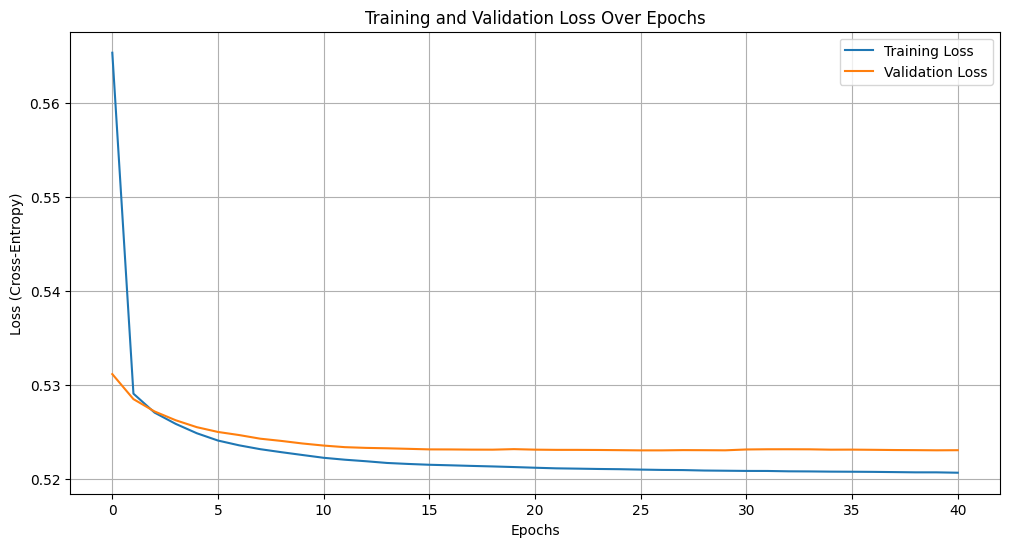

In [18]:
# Plot training and validation loss over epochs on the same graph
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid()

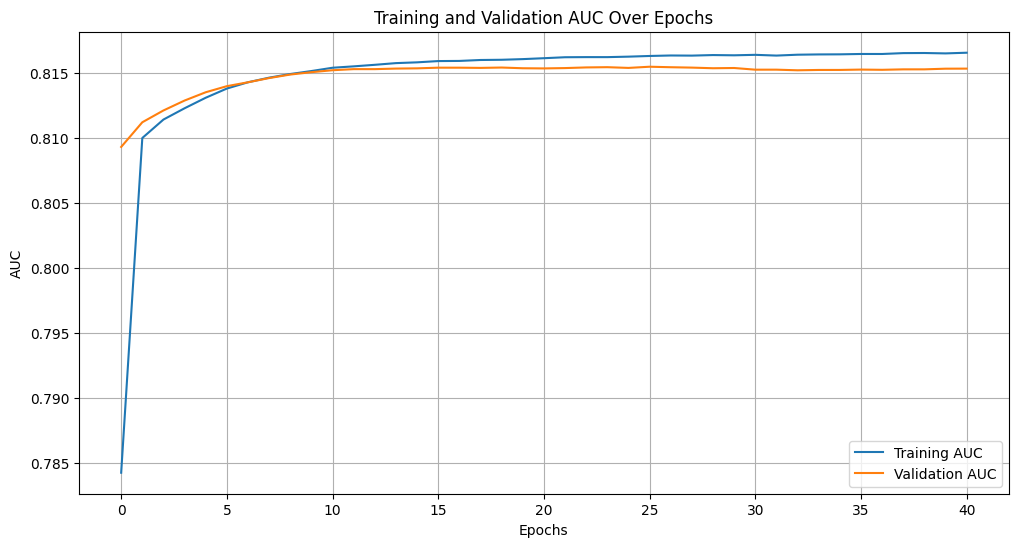

In [19]:
# Plot training and validation AUC over epochs on the same graph
plt.figure(figsize=(12, 6))
plt.plot(history.history["AUC"], label="Training AUC")
plt.plot(history.history["val_AUC"], label="Validation AUC")
plt.title("Training and Validation AUC Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()
plt.grid()

In [20]:
# Evaluate the model on the test set using AUC-ROC 
test_loss, test_auc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test AUC: {test_auc:.4f}')

Test AUC: 0.8149


In [21]:
# Confusion matrix and classification report
y_pred_prob = model.predict(X_test)
y_pred_prob_val = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)
y_pred_val = (y_pred_prob_val > 0.5).astype(int)

880/880 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [22]:
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72      7037
           1       0.72      0.79      0.75      7036

    accuracy                           0.74     14073
   macro avg       0.74      0.74      0.74     14073
weighted avg       0.74      0.74      0.74     14073



Confusion Matrix:


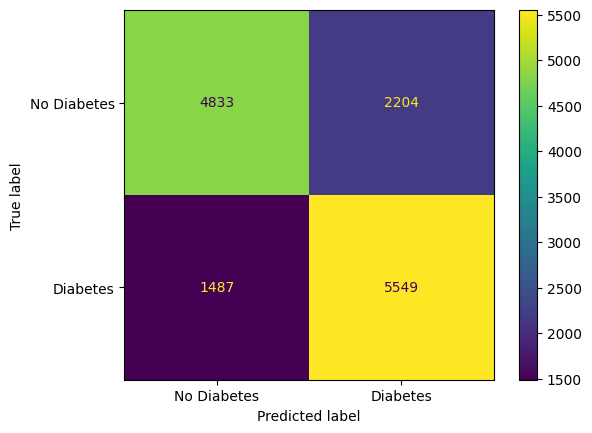

In [23]:
print("Confusion Matrix:")
cm = confusion_matrix(y_val, y_pred_val)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Diabetes", "Diabetes"]) 
cm_display.plot()
plt.show() 

### Analysis of the decision threshold

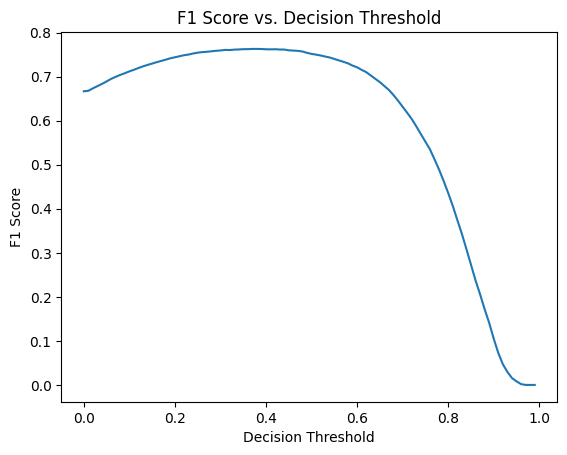

In [24]:
# Generation of the F1 curve based on the decision threshold
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]

plt.plot(thresholds, f1_scores)
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.show()

In [25]:
max_f1_index = np.argmax(f1_scores)
optimal_threshold = thresholds[max_f1_index]
print(f"Optimal Threshold: {optimal_threshold:.2f} with F1 Score: {f1_scores[max_f1_index]:.4f}")

Optimal Threshold: 0.37 with F1 Score: 0.7629


In [26]:
# Confusion matrix and classification report
y_pred_prob_val = model.predict(X_val)
y_pred_val = (y_pred_prob_val > optimal_threshold).astype(int)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.57      0.68      7037
           1       0.67      0.89      0.76      7036

    accuracy                           0.73     14073
   macro avg       0.75      0.73      0.72     14073
weighted avg       0.75      0.73      0.72     14073



Confusion Matrix:


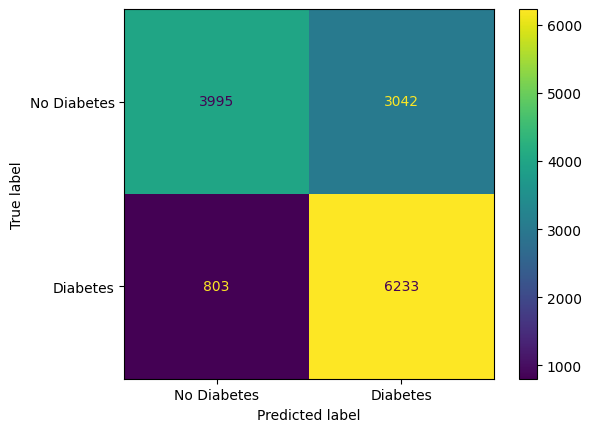

In [27]:
print("Confusion Matrix:")
cm_val = confusion_matrix(y_val, y_pred_val)
cm_display_val = ConfusionMatrixDisplay(confusion_matrix = cm_val, display_labels = ["No Diabetes", "Diabetes"]) 
cm_display_val.plot()
plt.show() 

### Save Model

In [28]:
# Model versioning: backup in .h5 format with timestamp and parameters
model.save('..\\models\\model_baseline.h5')

## Extended MLP (deeper layers or dropout)

### Building the Model

In [29]:
# Building the MLP model
model_extended = Sequential(
    [
        Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(4, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)
model_extended.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["AUC"],
)
model_extended.summary()

c:\Users\ethan\OneDrive\Documents\Strathmore\CESI\deep_learning\Personal\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601 (10.16 KB)

 Trainable params: 2,601 (10.16 KB)

 Non-trainable params: 0 (0.00 B)

### Training the Model

In [30]:
# Train the model
history_extended = model_extended.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
    class_weight=class_weights,
)

Epoch 1/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - AUC: 0.7547 - loss: 0.5912 - val_AUC: 0.8115 - val_loss: 0.5320
Epoch 2/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.7932 - loss: 0.5481 - val_AUC: 0.8127 - val_loss: 0.5338
Epoch 3/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8003 - loss: 0.5408 - val_AUC: 0.8135 - val_loss: 0.5298
Epoch 4/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8036 - loss: 0.5377 - val_AUC: 0.8145 - val_loss: 0.5282
Epoch 5/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.8043 - loss: 0.5360 - val_AUC: 0.8150 - val_loss: 0.5283
Epoch 6/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8069 - loss: 0.5339 - val_AUC: 0.8151 - val_loss: 0.5256
Epoch 7/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8067 - loss: 0.5345 - val_AUC: 0.8155 - val_loss: 0.5259
Epoch 8/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8076 - loss: 0.5327 - val_AUC: 0.8154 - val_loss: 0.5295
Epoch 9/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AU

### Evaluate the Model

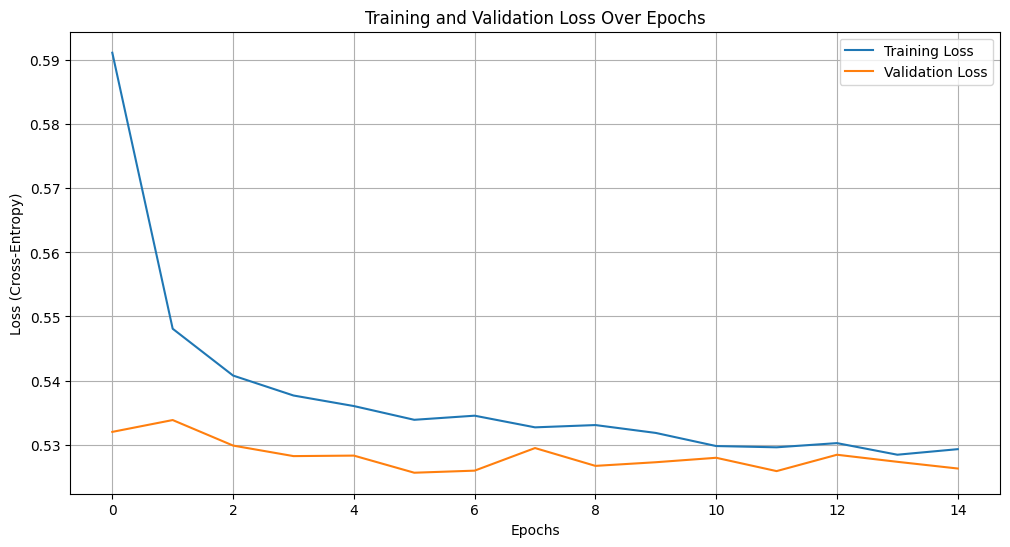

In [31]:
# Plot training and validation loss over epochs on the same graph
plt.figure(figsize=(12, 6))
plt.plot(history_extended.history["loss"], label="Training Loss")
plt.plot(history_extended.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid()

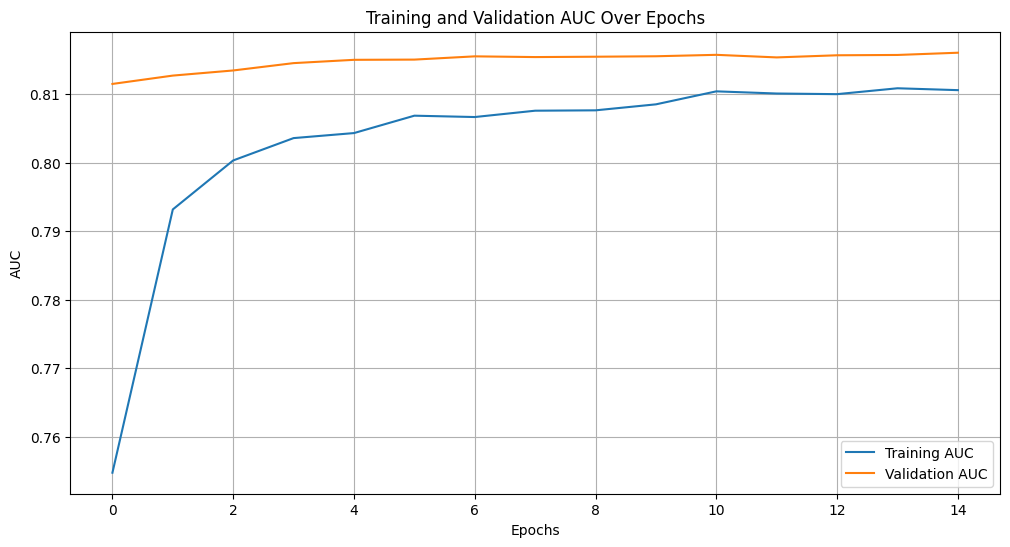

In [32]:
# Plot training and validation AUC over epochs on the same graph
plt.figure(figsize=(12, 6))
plt.plot(history_extended.history["AUC"], label="Training AUC")
plt.plot(history_extended.history["val_AUC"], label="Validation AUC")
plt.title("Training and Validation AUC Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()
plt.grid()

In [33]:
# Evaluate the model on the test set using AUC-ROC 
test_loss_extended, test_auc_extended = model_extended.evaluate(X_test, y_test, verbose=0)
print(f'Test AUC: {test_auc_extended:.4f}')

Test AUC: 0.8108


In [34]:
# Confusion matrix and classification report
y_pred_prob_extended = model_extended.predict(X_test)
y_pred_extended = (y_pred_prob_extended > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_extended))

880/880 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.63      0.70     14072
           1       0.69      0.84      0.76     14073

    accuracy                           0.73     28145
   macro avg       0.75      0.73      0.73     28145
weighted avg       0.75      0.73      0.73     28145



Confusion Matrix:


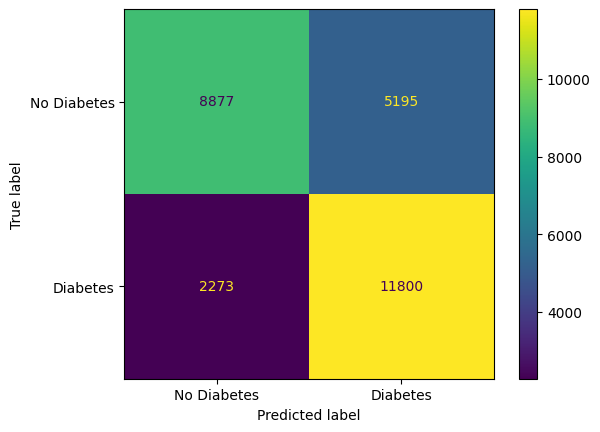

In [35]:
print("Confusion Matrix:")
cm_extended = confusion_matrix(y_test, y_pred_extended)
cm_display_extended = ConfusionMatrixDisplay(confusion_matrix = cm_extended, display_labels = ["No Diabetes", "Diabetes"]) 
cm_display_extended.plot()
plt.show() 

### Analysis of the decision threshold

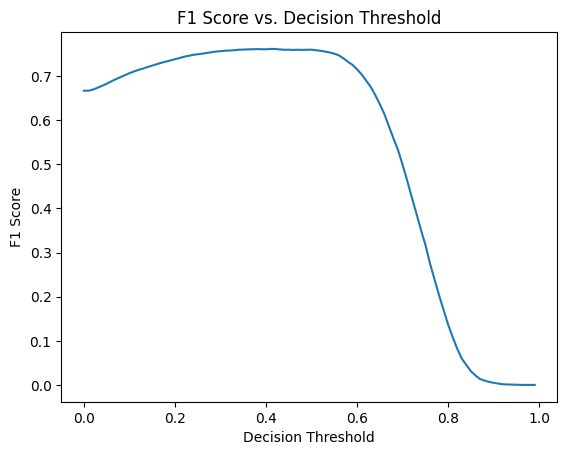

In [36]:
# Generation of the F1 curve based on the decision threshold
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores_extended = [f1_score(y_test, (y_pred_prob_extended > t).astype(int)) for t in thresholds]

plt.plot(thresholds, f1_scores_extended)
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.show()

In [37]:
max_f1_index_extended = np.argmax(f1_scores_extended)
optimal_threshold_extended = thresholds[max_f1_index_extended]
print(f"Optimal Threshold: {optimal_threshold_extended:.2f} with F1 Score: {f1_scores_extended[max_f1_index_extended]:.4f}")

Optimal Threshold: 0.41 with F1 Score: 0.7614


In [38]:
# Confusion matrix and classification report
y_pred_prob_val_extended = model_extended.predict(X_val)
y_pred_val_extended = (y_pred_prob_val_extended > optimal_threshold_extended).astype(int)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val_extended))

440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.57      0.67      7037
           1       0.67      0.88      0.76      7036

    accuracy                           0.72     14073
   macro avg       0.75      0.72      0.72     14073
weighted avg       0.75      0.72      0.72     14073



Confusion Matrix:


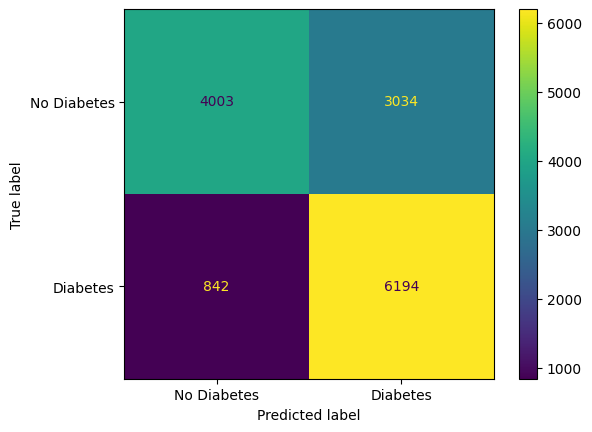

In [39]:
print("Confusion Matrix:")
cm_val_extended = confusion_matrix(y_val, y_pred_val_extended)
cm_display_val_extended = ConfusionMatrixDisplay(confusion_matrix = cm_val_extended, display_labels = ["No Diabetes", "Diabetes"]) 
cm_display_val_extended.plot()
plt.show() 

### Save Model

In [40]:
# Model versioning: backup in .h5 format with timestamp and parameters
model_extended.save('..\\models\\model_extended.h5')

## ResNet-like Dense MLP (with skip connections on dense layers)

### Building the Model

In [41]:
# Input layer
inputs = Input(shape=(X_train.shape[1],))

# First dense block
x1 = Dense(32, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01))(inputs)
x2 = Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01))(x1)

# Skip connection from input to next block
skip1 = Dense(16, activation="linear", kernel_regularizer=keras.regularizers.l2(0.01))(inputs)
add1 = Add()([x2, skip1])

# Second dense block
x3 = Dense(8, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01))(add1)
x4 = Dense(4, activation="relu", kernel_regularizer=keras.regularizers.l2(0.01))(x3)

# Skip connection from add1 to next block
skip2 = Dense(4, activation="linear", kernel_regularizer=keras.regularizers.l2(0.01))(add1)
add2 = Add()([x4, skip2])

# Output layer
outputs = Dense(1, activation="sigmoid")(add2)

# Build and compile model
model_resnet = Model(inputs=inputs, outputs=outputs)
model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["AUC"],
)
model_resnet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │        352 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │        528 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │        176 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16)        │          0 │ dense_9[0][0],    │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 8)         │        136 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 4)         │         36 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 4)         │         68 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 4)         │          0 │ dense_12[0][0],   │
│                     │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1)         │          5 │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,301 (5.08 KB)

 Trainable params: 1,301 (5.08 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Train the model
history_resnet = model_resnet.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
    class_weight=class_weights,
)

Epoch 1/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - AUC: 0.7964 - loss: 0.8659 - val_AUC: 0.8112 - val_loss: 0.6609
Epoch 2/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.8087 - loss: 0.6159 - val_AUC: 0.8110 - val_loss: 0.5860
Epoch 3/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.8086 - loss: 0.5733 - val_AUC: 0.8108 - val_loss: 0.5626
Epoch 4/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8086 - loss: 0.5580 - val_AUC: 0.8107 - val_loss: 0.5532
Epoch 5/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8086 - loss: 0.5516 - val_AUC: 0.8107 - val_loss: 0.5488
Epoch 6/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8087 - loss: 0.5483 - val_AUC: 0.8107 - val_loss: 0.5463
Epoch 7/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8087 - loss: 0.5463 - val_AUC: 0.8108 - val_loss: 0.5446
Epoch 8/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.8088 - loss: 0.5449 - val_AUC: 0.8110 - val_loss: 0.5434
Epoch 9/50
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AU

### Evaluate the Model

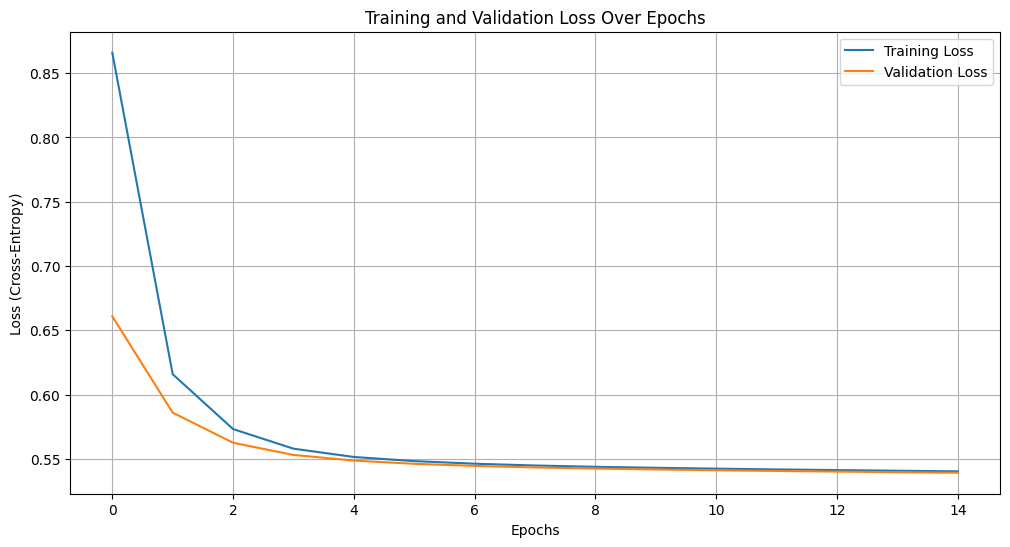

In [43]:
# Plot training and validation loss over epochs on the same graph
plt.figure(figsize=(12, 6))
plt.plot(history_resnet.history["loss"], label="Training Loss")
plt.plot(history_resnet.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (Cross-Entropy)")
plt.legend()
plt.grid()

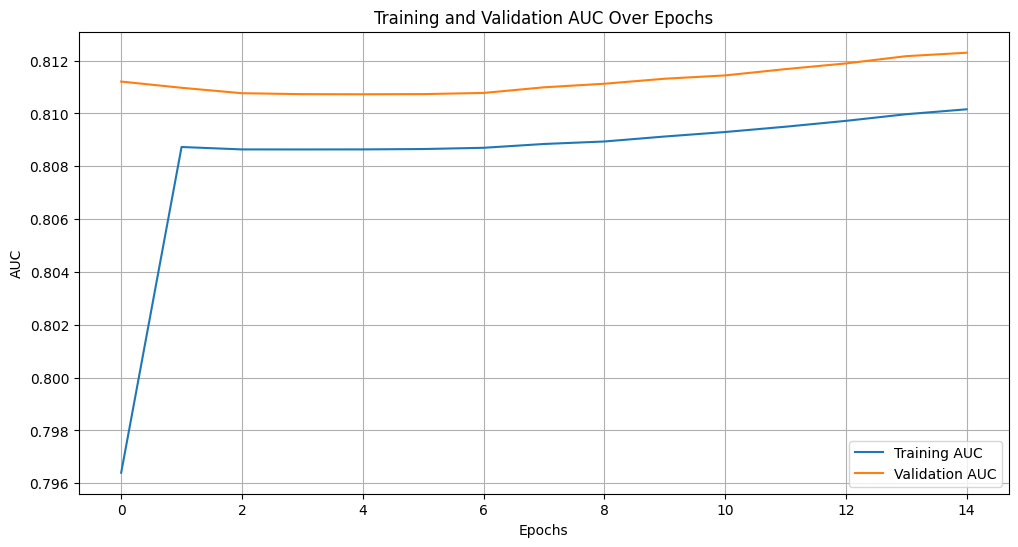

In [44]:
# Plot training and validation AUC over epochs on the same graph
plt.figure(figsize=(12, 6))
plt.plot(history_resnet.history["AUC"], label="Training AUC")
plt.plot(history_resnet.history["val_AUC"], label="Validation AUC")
plt.title("Training and Validation AUC Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()
plt.grid()

In [45]:
# Evaluate the model on the test set using AUC-ROC 
test_loss, test_auc = model_resnet.evaluate(X_test, y_test, verbose=0)
print(f'Test AUC: {test_auc:.4f}')

Test AUC: 0.8081


In [46]:
# Confusion matrix and classification report
y_pred_prob_resnet = model_resnet.predict(X_test)
y_pred_resnet = (y_pred_prob_resnet > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_resnet))

880/880 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.67      0.72     14072
           1       0.71      0.80      0.75     14073

    accuracy                           0.74     28145
   macro avg       0.74      0.74      0.73     28145
weighted avg       0.74      0.74      0.73     28145



Confusion Matrix:


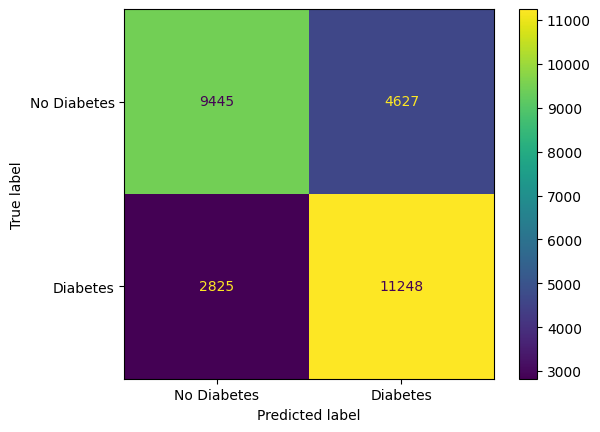

In [47]:
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_resnet)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Diabetes", "Diabetes"]) 
cm_display.plot()
plt.show() 

### Analysis of the decision threshold

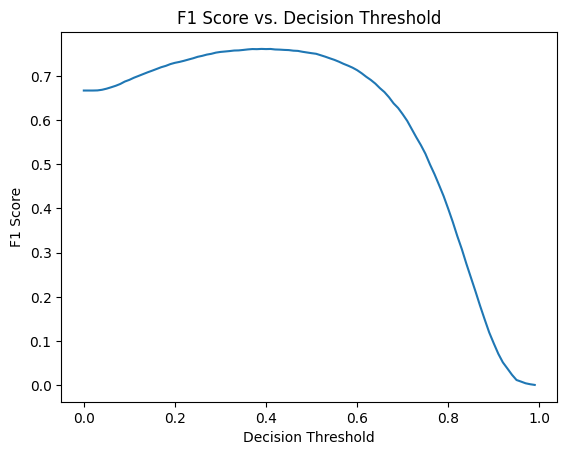

In [48]:
# Generation of the F1 curve based on the decision threshold
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores_resnet = [f1_score(y_test, (y_pred_prob_resnet > t).astype(int)) for t in thresholds]

plt.plot(thresholds, f1_scores_resnet)
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.show()

In [49]:
max_f1_index_resnet = np.argmax(f1_scores_resnet)
optimal_threshold_resnet = thresholds[max_f1_index_resnet]
print(f"Optimal Threshold: {optimal_threshold_resnet:.2f} with F1 Score: {f1_scores_resnet[max_f1_index_resnet]:.4f}")

Optimal Threshold: 0.39 with F1 Score: 0.7608


In [50]:
# Confusion matrix and classification report
y_pred_prob_val_resnet = model_resnet.predict(X_val)
y_pred_val_resnet = (y_pred_prob_val_resnet > optimal_threshold_resnet).astype(int)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val_resnet))

440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.55      0.66      7037
           1       0.67      0.89      0.76      7036

    accuracy                           0.72     14073
   macro avg       0.75      0.72      0.71     14073
weighted avg       0.75      0.72      0.71     14073



Confusion Matrix:


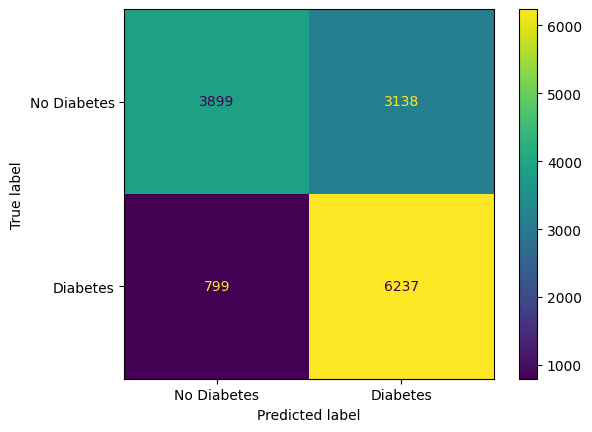

In [51]:
print("Confusion Matrix:")
cm_val_resnet = confusion_matrix(y_val, y_pred_val_resnet)
cm_display_val_resnet = ConfusionMatrixDisplay(confusion_matrix = cm_val_resnet, display_labels = ["No Diabetes", "Diabetes"]) 
cm_display_val_resnet.plot()
plt.show() 

### Save the Model

In [52]:
# Model versioning: backup in .h5 format with timestamp and parameters
model_resnet.save('..\\models\\model_resnet.h5')

## Comparative Analysis of Models

In [53]:
# Save the optimal thresholds for all models in a single file
with open('..\\models\\best_thresholds.txt', 'w') as f:
    f.write(f"Baseline Model Optimal Threshold: {optimal_threshold:.2f} with F1 Score: {f1_scores[max_f1_index]:.4f}\n")
    f.write(f"Extended Model Optimal Threshold: {optimal_threshold_extended:.2f} with F1 Score: {f1_scores_extended[max_f1_index_extended]:.4f}\n")
    f.write(f"ResNet Model Optimal Threshold: {optimal_threshold_resnet:.2f} with F1 Score: {f1_scores_resnet[max_f1_index_resnet]:.4f}\n")

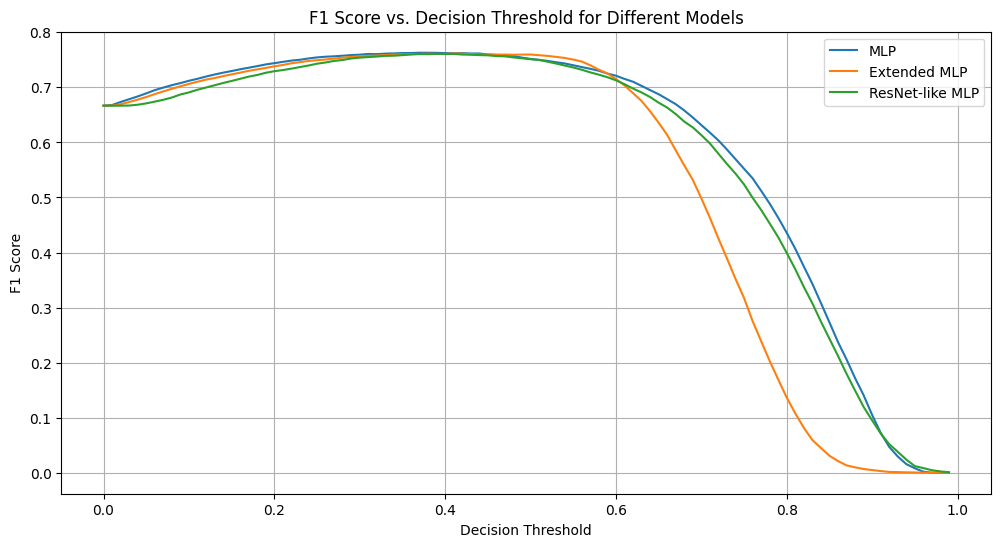

In [54]:
# Plot comparison of F1 scores for the three models before and after threshold optimization
plt.figure(figsize=(12, 6))
plt.plot(thresholds, f1_scores, label="MLP")
plt.plot(thresholds, f1_scores_extended, label="Extended MLP")
plt.plot(thresholds, f1_scores_resnet, label="ResNet-like MLP")
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold for Different Models")
plt.legend()
plt.grid()

In [55]:
# Compare classification reports for the three models at their optimal thresholds
print("\nClassification Report for MLP:")
print(classification_report(y_val, (y_pred_prob_val > optimal_threshold).astype(int)))
print("\nClassification Report for Extended MLP:")
print(classification_report(y_val, (y_pred_prob_val_extended > optimal_threshold_extended).astype(int)))
print("\nClassification Report for ResNet-like MLP:")
print(classification_report(y_val, (y_pred_prob_val_resnet > optimal_threshold_resnet).astype(int)))


Classification Report for MLP:
              precision    recall  f1-score   support

           0       0.83      0.57      0.68      7037
           1       0.67      0.89      0.76      7036

    accuracy                           0.73     14073
   macro avg       0.75      0.73      0.72     14073
weighted avg       0.75      0.73      0.72     14073


Classification Report for Extended MLP:
              precision    recall  f1-score   support

           0       0.83      0.57      0.67      7037
           1       0.67      0.88      0.76      7036

    accuracy                           0.72     14073
   macro avg       0.75      0.72      0.72     14073
weighted avg       0.75      0.72      0.72     14073


Classification Report for ResNet-like MLP:
              precision    recall  f1-score   support

           0       0.83      0.55      0.66      7037
           1       0.67      0.89      0.76      7036

    accuracy                           0.72     14073
   macro av

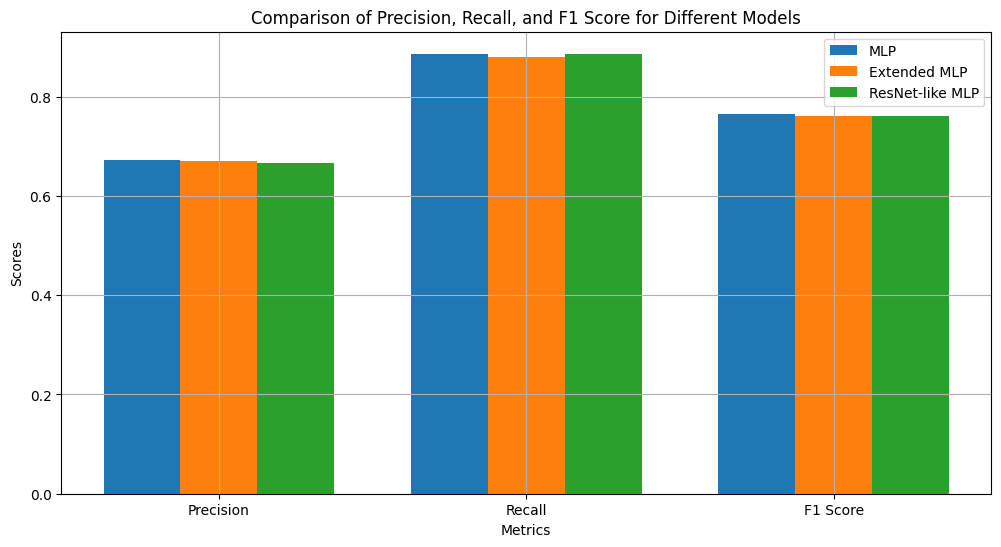

In [56]:
# Graph the differences in precision, recall, and F1 score for the three models at their optimal thresholds
precision_mlp = precision_score(y_val, (y_pred_prob_val > optimal_threshold).astype(int))
recall_mlp = recall_score(y_val, (y_pred_prob_val > optimal_threshold).astype(int))
f1_mlp = f1_score(y_val, (y_pred_prob_val > optimal_threshold).astype(int))
precision_mlp_extended = precision_score(y_val, (y_pred_prob_val_extended > optimal_threshold_extended).astype(int))
recall_mlp_extended = recall_score(y_val, (y_pred_prob_val_extended > optimal_threshold_extended).astype(int))
f1_mlp_extended = f1_score(y_val, (y_pred_prob_val_extended > optimal_threshold_extended).astype(int))
precision_resnet = precision_score(y_val, (y_pred_prob_val_resnet > optimal_threshold_resnet).astype(int))
recall_resnet = recall_score(y_val, (y_pred_prob_val_resnet > optimal_threshold_resnet).astype(int))
f1_resnet = f1_score(y_val, (y_pred_prob_val_resnet > optimal_threshold_resnet).astype(int))

metrics = ["Precision", "Recall", "F1 Score"]
mlp_metrics = [precision_mlp, recall_mlp, f1_mlp]
mlp_extended_metrics = [precision_mlp_extended, recall_mlp_extended, f1_mlp_extended]
resnet_metrics = [precision_resnet, recall_resnet, f1_resnet]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, mlp_metrics, width, label="MLP")
plt.bar(x, mlp_extended_metrics, width, label="Extended MLP")
plt.bar(x + width, resnet_metrics, width, label="ResNet-like MLP")
plt.xlabel("Metrics")
plt.ylabel("Scores")
plt.title("Comparison of Precision, Recall, and F1 Score for Different Models")
plt.xticks(x, metrics)
plt.legend()
plt.grid()

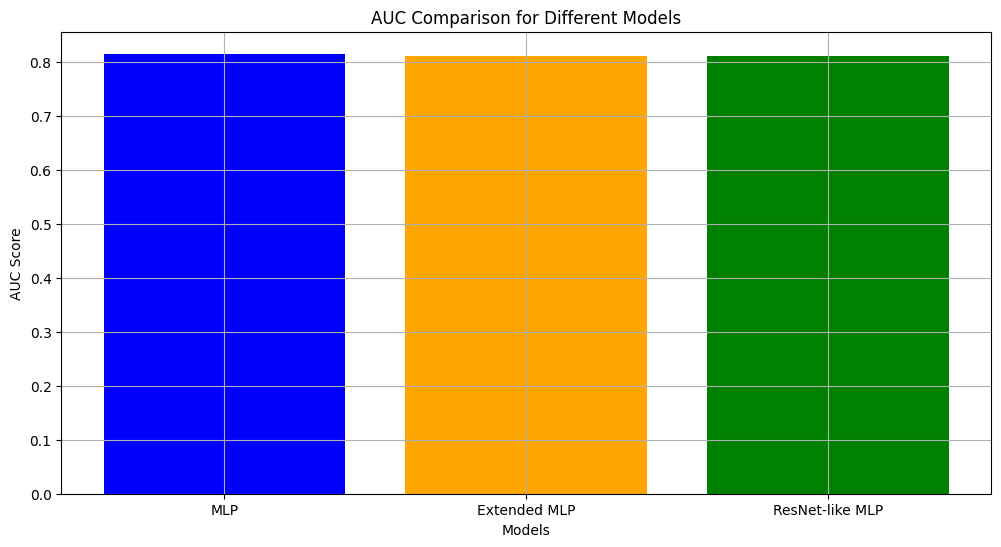

In [57]:
# AUC comparison for the three models
test_auc_mlp = roc_auc_score(y_val, y_pred_prob_val)
test_auc_mlp_extended = roc_auc_score(y_val, y_pred_prob_val_extended)
test_auc_resnet = roc_auc_score(y_val, y_pred_prob_val_resnet)

plt.figure(figsize=(12, 6))
models = ["MLP", "Extended MLP", "ResNet-like MLP"]
auc_scores = [test_auc_mlp, test_auc_mlp_extended, test_auc_resnet]
plt.bar(models, auc_scores, color=["blue", "orange", "green"])
plt.xlabel("Models")
plt.ylabel("AUC Score")
plt.title("AUC Comparison for Different Models")
plt.grid()

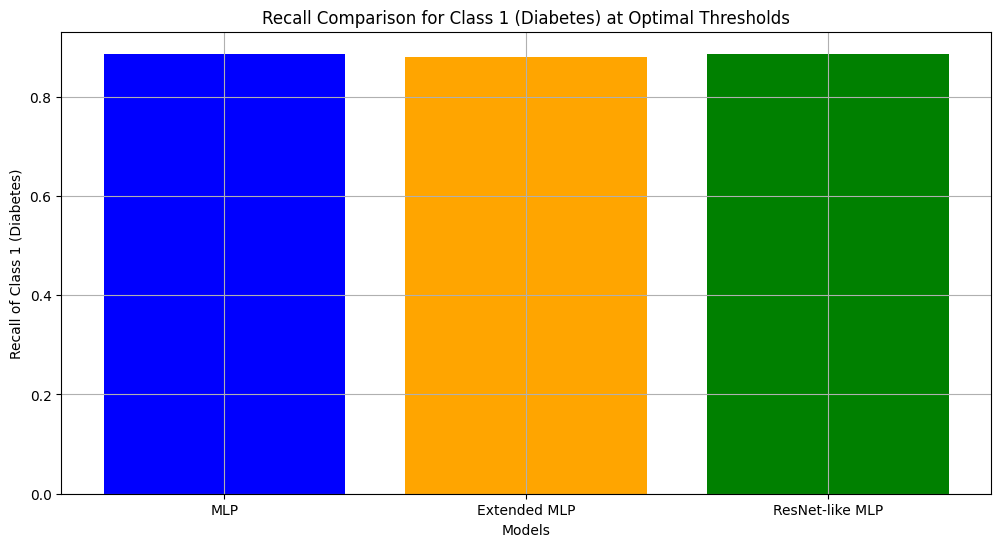

In [58]:
# Graph comparing the recall of class 1 (diabetes) for the three models at their optimal thresholds
recall_mlp = recall_score(y_val, (y_pred_prob_val > optimal_threshold).astype(int))
recall_mlp_extended = recall_score(y_val, (y_pred_prob_val_extended > optimal_threshold_extended).astype(int))
recall_resnet = recall_score(y_val, (y_pred_prob_val_resnet > optimal_threshold_resnet).astype(int))
plt.figure(figsize=(12, 6))
models = ["MLP", "Extended MLP", "ResNet-like MLP"]
recall_scores = [recall_mlp, recall_mlp_extended, recall_resnet]
plt.bar(models, recall_scores, color=["blue", "orange", "green"])
plt.xlabel("Models")
plt.ylabel("Recall of Class 1 (Diabetes)")
plt.title("Recall Comparison for Class 1 (Diabetes) at Optimal Thresholds")
plt.grid()


440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


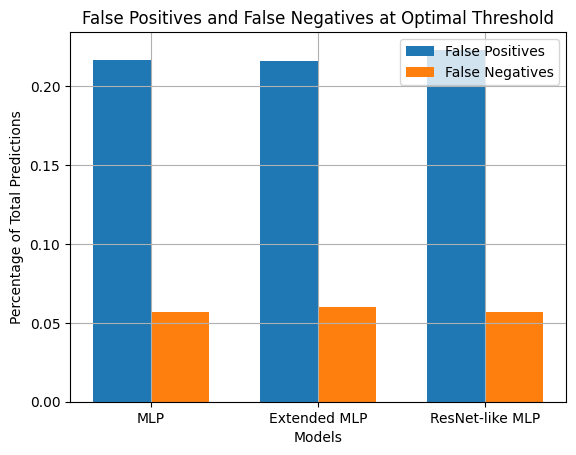

In [59]:
# Plot comparison of percentage of false positives and false negatives for the three models at the optimal threshold on the same graph
optimal_thresholds = [optimal_threshold, optimal_threshold_extended, optimal_threshold_resnet]
models = ["MLP", "Extended MLP", "ResNet-like MLP"]
false_positives = []
false_negatives = []
for model, threshold in zip([model, model_extended, model_resnet], optimal_thresholds):
    y_pred_prob = model.predict(X_val)
    y_pred = (y_pred_prob > threshold).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    fp = cm[0][1] / cm.sum()
    fn = cm[1][0] / cm.sum()
    false_positives.append(fp)
    false_negatives.append(fn)
x = np.arange(len(models))
width = 0.35
plt.bar(x - width/2, false_positives, width, label='False Positives')
plt.bar(x + width/2, false_negatives, width, label='False Negatives')
plt.xlabel('Models')
plt.ylabel('Percentage of Total Predictions')
plt.title('False Positives and False Negatives at Optimal Threshold')
plt.xticks(x, models)
plt.legend()
plt.grid()